# Homework 2: Probability Models

BEE 4850/5850

**Name**:

**ID**:

> **Due Date**
>
> Friday, 2/21/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice developing and
working with probability models for data.

-   Problem 1 asks you to fit a sea-level rise model using normal
    residuals and to assess the validity of that assumption.
-   Problem 2 asks you to model the time series of hourly
    weather-related variability at a tide gauge using an autoregressive
    model.
-   Problem 3 asks you to use Poisson regression to predict salamander
    counts based on environmental data.
-   Problem 4 (only required for students in BEE 5850) asks you to look
    at the impact of the gender of hurricane names on deaths[1].

[1] Yes, seriously. Ish. Trust me, I know.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [86]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `c:\Users\aliap\Cornell\BEE 5850\hw02-AAPShabazz`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [87]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization toolsCS

## Problems

### Scoring

-   Problem 1 is worth 7 points.
-   Problem 2 is worth 6 points.
-   Problem 3 is worth 7 points.
-   Problem 4 is worth 5 points.

### Problem 1

Consider the following sea-level rise model from [Grinsted et al
(2010)](https://doi.org/10.1007/s00382-008-0507-2), which models
sea-level rise based on a linear relationship between global mean
temperature and an “equilibrium” sea level:

$$\begin{align*}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{align*}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm/$^\circ$C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$C (in mm).

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data.
-   Fit the model under the assumption of Gaussian i.i.d. residuals
    (include both an uncertain model error term and the standard
    deviation of the observations in the probability model
    specification) by maximizing the likelihood. Report the parameter
    estimates. Note that you will need another parameter $S_0$ for the
    initial sea level. What can you conclude about the relationship
    between global mean temperature increases and global mean sea level
    rise rates?
-   How appropriate was the Gaussian i.i.d. probability model for the
    residuals? Use any needed quantitative or qualitative assessments of
    goodness of fit to justify your answer. If this was not an
    appropriate probability model, what would you change?

In [148]:

global_mean_temp = CSV.read("data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv", DataFrame )
global_mean_sea_level = CSV.read("data/CSIRO_Recons_gmsl_yr_2015.csv", DataFrame)

m1= 0
for i = 131:150
    m1 += global_mean_temp[i,:]["Anomaly (deg C)"]
end
m1 = m1/20

m2= 0
for i = 101:120
    m2 += global_mean_sea_level[i,:]["GMSL (mm)"]
end
m2 = m2/20



# Normalize Data

for j = 1:174
    global_mean_temp[j,:]["Anomaly (deg C)"] = global_mean_temp[j,:]["Anomaly (deg C)"]-m1
end

for j = 1:134
    global_mean_sea_level[j,:]["GMSL (mm)"] = global_mean_sea_level[j,:]["GMSL (mm)"] - m2
end

global_mean_temp_sub = global_mean_temp[31:164,:]

global_mean_temp_stdv = global_mean_temp[31:164,"Upper confidence limit (97.5%)"]

for k = 1:134
    global_mean_temp_stdv[k] = (global_mean_temp[k,"Upper confidence limit (97.5%)"] - global_mean_temp[k,"Lower confidence limit (2.5%)"])/2
end




In [187]:
function sealevel(S₀, tau, a, T, b)
    # set up model parameters
   
    Δt = 1 # annual timestep [s]
    S = zeros(size(T)[1])
    S[1] = S₀

    for i in 1:length(S)-1
        Seq = a*T[i,"Anomaly (deg C)"] + b
        S[i+1] = S[i] + ((Seq - S[i])/tau)* Δt
    end
    
    return S
end

sealevel (generic function with 1 method)

In [152]:
a = zeros(size(global_mean_temp_sub))
length(a)

536

In [205]:
function gaussian_iid_homosked(params, T, T_err)
    S₀, tau, a, b, σ = params 
    sim = sealevel(S₀, tau, a, T, b)
    loglike = sum(logpdf.(Normal.(sim, sqrt.(σ^2 .+ T_err.^2)), T[!,"Anomaly (deg C)"]))
    return loglike
end
lower = [-250, 200, 1000, 500, 0]
upper = [100, 1700, 5000, 5000, 500]
init = [-35.0, 317.0, 2560.0, 1360.0, 50.0]

result = Optim.optimize(params -> -gaussian_iid_homosked(params, global_mean_temp_sub, global_mean_temp_stdv), lower, upper, init)
θ_iid = result.minimizer

5-element Vector{Float64}:
    3.3116047333471053
 1699.9999999991242
 1215.2595805644157
  500.0000000002579
    3.4589164750423986

S0 = 3.31; tau = 1700 (!); a = 1225; b = 500; σ = 3.45

The results indicate that mean temperature increases correlate positively with sea level increase with a model error of 3.45 (height units kept as mm). The gaussian model was somewhat appropriate as σ  and S0 appear to have converged on values squarely in between the constraits set (motivated by Table 1 from Grinsted et al.). Nevertheless, tau and b were completely driven by the limits set, even though there was not a strong intuition that motivated my selection of them (except for them apearing in Grinsted et al.). As such, the model is not unreasonable, but could be better.

### Problem 2

Tide gauge data is complicated to analyze because it is influenced by
different harmonic processes (such as the linear cycle). In this
problem, we will develop a model for this data using [NOAA data from the
Sewell’s Point tide
gauge](https://tidesandcurrents.noaa.gov/waterlevels.html?id=8638610)
outside of Norfolk, VA from `data/norfolk-hourly-surge-2015.csv`. This
is hourly data (in m) from 2015 and includes both the observed data
(`Verified (m)`) and the tide level predicted by NOAA’s sinusoidal model
for periodic variability, such as tides and other seasonal cycles
(`Predicted (m)`).

**In this problem**:

-   Load the data file. Take the difference between the observations and
    the sinusoidal predictions to obtain the tide level which could be
    attributed to weather-related variability (since for one year
    sea-level rise and other factors are unlikely to matter). Plot this
    data.
-   Develop an autoregressive (AR) model for the weather-related
    variability in the Norfolk tide gauge. Make sure to include your
    logic or exploratory analysis used in determining the model
    specification.
-   Use your model to simulate 1,000 realizations of hourly tide gauge
    observations by adding simulations from your AR model back to the
    predicted sinusoidal trend. What is the distribution of the maximum
    tide level? How does this compare to the observed value?

0.6160.4320.2420.084-0.006-0.0150.0750.210.3860.5750.6990.7340.6960.5690.3940.2020.034-0.058-0.067-0.0130.1450.30.4350.4940.4830.3920.2030.002-0.172-0.286-0.319-0.209-0.0290.2120.4350.5710.6080.5720.4510.2520.059-0.109-0.208-0.205-0.1180.0890.2840.4540.5040.4790.3480.152-0.044-0.181-0.241-0.191-0.0280.1960.4280.6170.720.7430.6890.5560.3620.142-0.005-0.072-0.0260.1320.3310.5410.6890.7380.6910.5650.3750.1820.0620.0120.0680.2490.4430.6660.8280.8970.8960.7970.6040.3640.1420.002-0.0580.0070.1410.2860.4970.6420.7120.5970.4380.2560.090.0130.0110.0690.1830.4130.6310.7580.850.740.5960.4050.1660.02-0.114-0.0990.0160.2290.4290.5340.6210.5680.4480.2730.089-0.069-0.172-0.183-0.0790.1110.280.4390.5680.6090.5530.3970.195-0.018-0.189-0.26-0.233-0.0920.080.2790.4410.5340.5490.460.3120.108-0.059-0.109-0.0630.1230.2880.4640.6090.6990.7060.5850.4630.3460.1730.0490.020.130.2450.3930.4960.5510.5650.5360.4180.250.079-0.039-0.108-0.0660.0420.1930.360.4920.5490.5320.4250.2380.02-0.132-0.231-0.226-0.1240.00.127

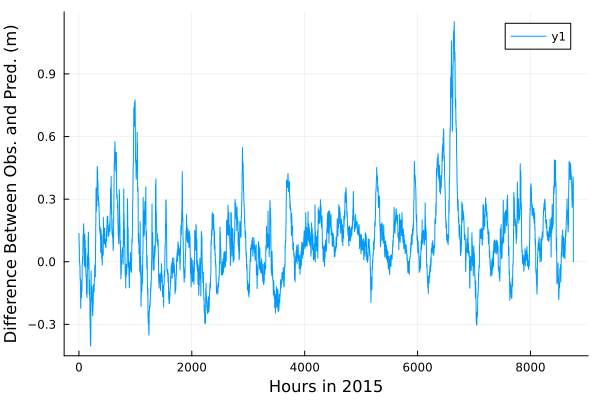

In [223]:
hrly_srg = CSV.read("data/norfolk-hourly-surge-2015.csv", DataFrame)
diff = zeros(size(hrly_srg)[1])
for i in 1:length(diff)-1
    print(hrly_srg[i,"Verified (m)"] )
    diff[i] = hrly_srg[i,"Verified (m)"] - hrly_srg[i,"Predicted (m)"]
end
plot(diff, xlabel= "Hours in 2015",ylabel="Difference Between Obs. and Pred. (m)")

In [279]:
function ar1_loglik_whitened(θ, dat)
    # subtract trend from data to make this mean-zero in this case
    ρ, σ = θ
    T = length(dat)
    ll = 0 # initialize log-likelihood counter
    for i = 1:T
        if i == 1
            ll += logpdf(Normal(0, sqrt(σ^2 / (1 - ρ^2))), dat[i])
        else
            ll += logpdf(Normal(ρ * dat[i-1], σ), dat[i])
        end
    end
    return ll
end

lower = [-0.3, 0.01] 
upper = [0.5, 1.5]
init = [0.25, 0.3]

optim_whitened = Optim.optimize(θ -> -ar1_loglik_whitened(θ, diff), lower, upper, init)
θ_wn_mle = round.(optim_whitened.minimizer; digits=2)
@show θ_wn_mle;



θ_wn_mle = [0.5, 0.12]


2-element Vector{Float64}:
 0.5
 0.12

The above is parameter-finding for an AR(1) model. The constrains and initial values were chosen by inspection of the above graph. The upper limit for ρ was adjusted by trying some values and seeing results below.

In [280]:

ρ = θ_wn_mle[1]
σ = θ_wn_mle[2]

ts_sim = zeros(length(diff))
# simulate AR(1) series for 1000 hours
for t = 1:999
    if t == 1
        ts_sim[t] = diff[1]
    else
        ts_sim[t] = rand(Normal(ρ * ts_sim[t-1], σ))
    end
end

new = zeros(1000)
for i in 1:999
    new[i] =  hrly_srg[i,"Predicted (m)"] + ts_sim[i]
end



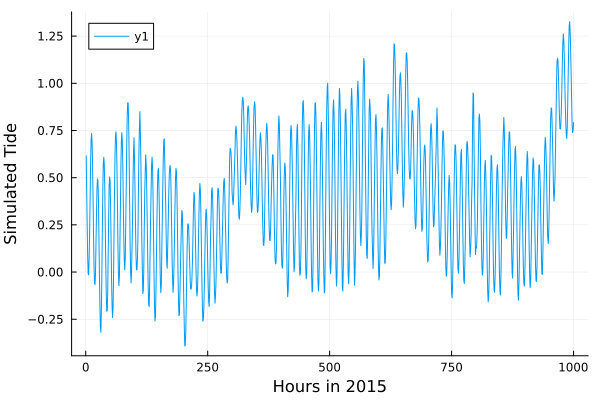

In [281]:
plot(hrly_srg[1:1000,"Verified (m)"], xlabel= "Hours in 2015",ylabel="Simulated Tide")


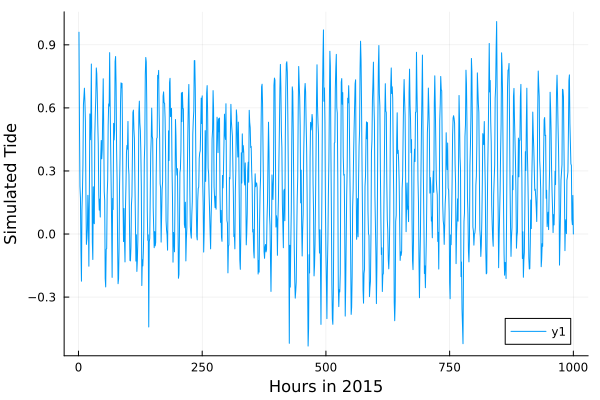

In [282]:
plot(new, xlabel= "Hours in 2015",ylabel="Simulated Tide")


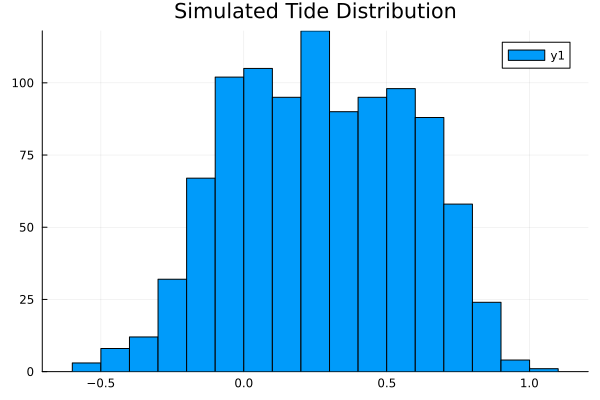

In [283]:

histogram(new, title ="Simulated Tide Distribution")


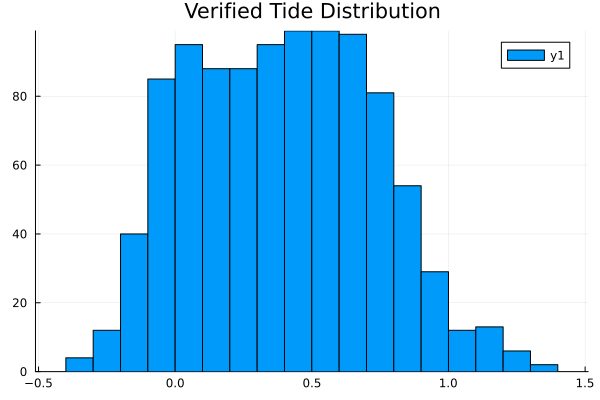

In [284]:

histogram(hrly_srg[1:1000,"Verified (m)"], title ="Verified Tide Distribution")


The simulated distribution is somewhat bimodal if ρ for the AR(1) is allowed to go higher, but at around 0.5, the distributions look similar. They appear potentially normally distributed, but wide.

## Problem 3

The file `data/salamanders.csv` contains counts of salamanders from 47
different plots of the same area in California, as well as the
percentage of ground cover and age of the forest in the plot. You would
like to see if you can use these data to predict the salamander counts
with a Poisson regression.

**In this problem**:

-   Load the data. You may need to standardize the predictors as they
    are much larger than the counts.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Plot the expected counts and 90% prediction intervals from your
    model. How well does the model predict the observed counts? In what
    ways does it do a good or bad job?
-   Can you improve the model by including forest age? Why do you think
    this helps or does not help with prediction?

In [ ]:
sala = CSV.read("data/salamanders.csv", DataFrame)

# Use Predictor means for standarization later
pctc_stand = sala[!,"PCTCOVER"] .- mean(sala[!,"PCTCOVER"])
forr_stand = sala[!,"FORESTAGE"] .- mean(sala[!,"FORESTAGE"])

function fish_model(params, pctc, salamanders)
    β₀, β₁  = params
    λ = exp.(β₀ .+ β₁ * pctc)
    loglik = sum(logpdf.(Poisson.(λ), salamanders))
end

lb = [-1, -1]
ub = [1, 1]
init = [0.0, 0.0]

optim_out = optimize(θ -> -fish_model(θ, pctc_stand, sala[!,"SALAMAN"]), lb, ub, init)
θ_mle = optim_out.minimizer
@show round.(θ_mle; digits=1);

round.(θ_mle; digits = 1) = [0.4, 0.0]


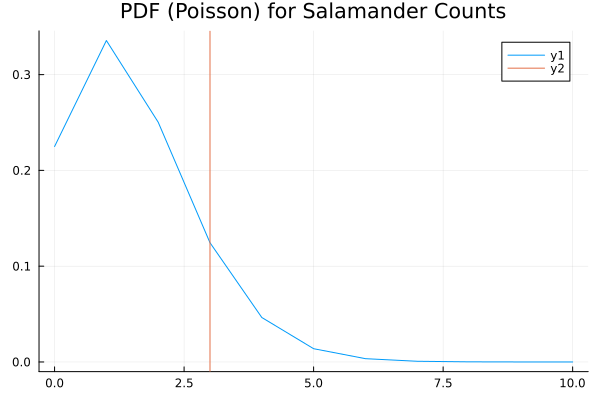

In [335]:
plot(0:1:10,pdf(Poisson(exp(0.4)),0:1:10),title="PDF (Poisson) for Salamander Counts")
vline!([3])


In [ ]:
# Expected value = exp(0.4)
# One-sided 90% interval in graph above
quantile(Poisson(exp(0.4)),0.9)

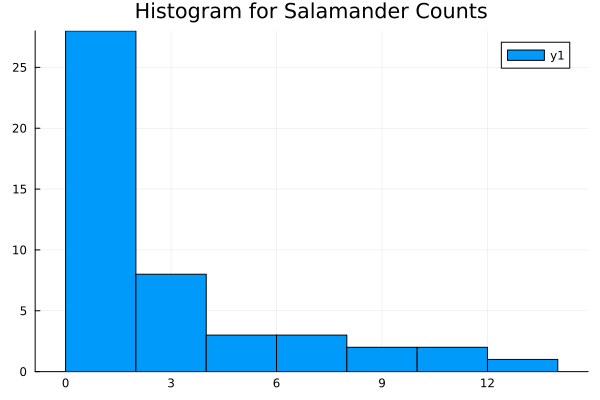

In [338]:
histogram(sala[!,"SALAMAN"], title = "Histogram for Salamander Counts")

The model does a somewhat acceptable job, but the real data is so skewed that it is hard for the Poisson distribution to accurately capture it. The mean is well-reflected, but this should be a given. Also, the 90% interval visually seems accurate. As seen below, adding another variable does not change the model at all. This is because the predictor variables are not highly correlated with the results.

In [ ]:

function fish_model_with_forr(params, pctc, forr, salamanders)
    β₀, β₁, β₂ = params
    λ = exp.(β₀ .+ β₁ * pctc + β₂ * forr)
    loglik = sum(logpdf.(Poisson.(λ), salamanders))
end

lb = [-10, -10, -10.0]
ub = [10, 10, 10]
init = [0.0, 0.0, 0.0]

optim_out = optimize(θ -> -fish_model_with_forr(θ, pctc_stand, forr_stand, sala[!,"SALAMAN"]), lb, ub, init)
θ_mle = optim_out.minimizer
@show round.(θ_mle; digits=1);


round.(θ_mle; digits = 1) = [0.4, 0.0, -0.0]


### Problem 4

<span style="color:red;">GRADED FOR 5850 STUDENTS ONLY</span>

In 2014, [a paper was published in a prestigious
journal](https://www.pnas.org/doi/10.1073/pnas.1402786111) which claimed
that hurricanes with more feminine names are deadlier than hurricanes
with more masculine names because people take warnings about
female-named hurricanes less seriously[1]. The file
`data/Hurricanes.csv` contains the original data used in this analysis.
While we won’t replicate the specific analysis in this paper, let’s use
the data to look at this hypothesis.

**In this problem**:

-   One might interpret the hypothesis to claim that the impact of the
    name is strengthened by the the more powerful. A measure of
    hurricane strength is its minimum pressure (`min_pressure` in the
    dataset). Fit a model that predicts deaths (‘deaths’) using the
    femininity of the name (`femininity`) and minimum pressure (you may
    need to standardize the pressure).
-   Interpret the results by generating counterfactual simulations for
    hurricanes with the most feminine and masculine name scores. Plot
    the expected values and 90% prediction intervals from these two sets
    of simulations and compare with the observed storm deaths. Where
    does the model do well or not well? Does the effect size of the
    gender of the name seem plausible?
-   Conclude with a summary of your conclusions about the impact of the
    gender of a hurricane’s name on deaths. How might you change the
    approach in this problem to keep exploring this hypothesis, if at
    all?

[1] This paper has become a bit of a joke among statisticians, but let’s
take the hypothesis seriously for this problem’s sake.

In [367]:
hurr = CSV.read("data/Hurricanes.csv", DataFrame)

# Standardize Mean Pressure
mp_std = abs.(hurr[!,"min_pressure"] .- mean(hurr[!,"min_pressure"]))

function tds_hurr_loglik(θ, min_press, femininity, deaths)
    β₀, β₁, β, σ = θ # unpack parameter vector
    μ = β .+ β₀ * log.(min_press) .+ β₁ * log.(femininity) # find mean
    ll = sum(logpdf.(Normal.(μ, σ), deaths)) # compute log-likelihood
    return ll
end


lb = [-100.0, -100.0, -100.0, 1.0]
ub = [100.0, 100.0, 100.0, 100.0]
θ₀ = [0.0, 0.0, 0.0, 50.0]
optim_out = Optim.optimize(θ -> -tds_hurr_loglik(θ, mp_std, hurr[!,"femininity"], hurr[!,"deaths"]), lb, ub, θ₀)
θ_mle = round.(optim_out.minimizer; digits=0)
@show θ_mle;

θ_mle = [11.0, 7.0, -17.0, 39.0]


In [343]:
hurr = CSV.read("data/Hurricanes.csv", DataFrame)


Row,name,year,deaths,category,min_pressure,damage_norm,female,femininity
,String15,Int64,Int64,Int64,Int64,Int64,Int64,Float64
1,Easy,1950,2,3,960,1590,1,6.77778
2,King,1950,4,3,955,5350,0,1.38889
3,Able,1952,3,1,985,150,0,3.83333
4,Barbara,1953,1,1,987,58,1,9.83333
5,Florence,1953,0,1,985,15,1,8.33333
6,Carol,1954,60,3,960,19321,1,8.11111
7,Edna,1954,20,3,954,3230,1,8.55556
8,Hazel,1954,20,4,938,24260,1,9.44444
9,Connie,1955,0,3,962,2030,1,8.5


## References